In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
#When importing libraries that have several packages with corresponding functions
#If you know you will only need to use one specific function from a certain package
#It is better to simply import it directly, as seen below, since it is more efficient and allows for greater simplicity later on
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [5]:
mushrooms = pd.read_csv('/workspaces/DS-3021/extracted_data/MushroomDataset/primary_data.csv', sep=';')
mushrooms.head()

,family,name,class,cap-diameter,cap-shape,Cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,Spore-print-color,habitat,season
0,Amanita Family,Fly Agaric,p,"[10, 20]","[x, f]","[g, h]","[e, o]",[f],[e],NaN,...,[s],[y],[w],[u],[w],[t],"[g, p]",NaN,[d],"[u, a, w]"
1,Amanita Family,Panther Cap,p,"[5, 10]","[p, x]",[g],[n],[f],[e],NaN,...,NaN,[y],[w],[u],[w],[t],[p],NaN,[d],"[u, a]"
2,Amanita Family,False Panther Cap,p,"[10, 15]","[x, f]",NaN,"[g, n]",[f],[e],NaN,...,NaN,NaN,[w],[u],[w],[t],"[e, g]",NaN,[d],"[u, a]"
3,Amanita Family,The Blusher,e,"[5, 15]","[x, f]",NaN,[n],[t],NaN,NaN,...,[b],NaN,[w],[u],[w],[t],[g],NaN,[d],"[u, a]"
4,Amanita Family,Death Cap,p,"[5, 12]","[x, f]",[h],[r],[f],NaN,[c],...,NaN,NaN,[w],[u],[w],[t],"[g, p]",NaN,[d],"[u, a]"


Can we predict if a mushroom is edible or poisonous using stem color, the presence of rings. ring type, bruise or bleed, cap shape, and ring type?

In [7]:
mush = mushrooms[['class', 'stem-color', 'ring-type', 'has-ring', 'ring-type', 'does-bruise-or-bleed', 'cap-shape']]
mush.head()

,class,stem-color,ring-type,has-ring,ring-type,does-bruise-or-bleed,cap-shape
0,p,[w],"[g, p]",[t],"[g, p]",[f],"[x, f]"
1,p,[w],[p],[t],[p],[f],"[p, x]"
2,p,[w],"[e, g]",[t],"[e, g]",[f],"[x, f]"
3,e,[w],[g],[t],[g],[t],"[x, f]"
4,p,[w],"[g, p]",[t],"[g, p]",[f],"[x, f]"


In [11]:
mush_1h = pd.get_dummies(mush[['class', 'stem-color', 'ring-type', 'has-ring', 'ring-type', 'does-bruise-or-bleed', 'cap-shape']], drop_first=True)
mush_1h

,class_p,"stem-color_[e, n]","stem-color_[e, u, y]","stem-color_[e, y]",stem-color_[e],stem-color_[f],"stem-color_[g, w]","stem-color_[g, n]","stem-color_[g, r, n]","stem-color_[g, u, n]",...,"cap-shape_[p, x]",cap-shape_[p],"cap-shape_[s, o]",cap-shape_[s],"cap-shape_[x, f, s]","cap-shape_[x, f]","cap-shape_[x, o]","cap-shape_[x, p]","cap-shape_[x, s]",cap-shape_[x]
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
169,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
170,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
171,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
train, test = train_test_split(mush_1h, test_size=0.2, stratify=mush_1h['class_p'], random_state=22)
print(train.shape)
print(test.shape)

(138, 117)
(35, 117)


In [ ]:
#Check prevalence
Poisonous = train['class_p'].sum()
prev = Poisonous/138
print ("The prevalence in the train set is: ", prev)

The prevalence is:  0.5579710144927537


In [16]:
#Check prevalence
Poisonous = test['class_p'].sum()
prev = Poisonous/35
print ("The prevalence in the test set is: ", prev)

The prevalence in the test set is:  0.5428571428571428


In [20]:
import random
random.seed(1984)   # kNN is a random algorithm, so we use `random.seed(x)` to make results repeatable

X_train = train.drop(['class_p'], axis=1)
y_train = train['class_p'].values
X_test = test.drop(['class_p'], axis=1)
y_test = test['class_p'].values

neigh = KNeighborsClassifier(n_neighbors=9)
neigh.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

In [23]:
# calculate accuracy

accu = neigh.score(X_test, y_test)
print('The accuracy of my model on the testing set is:',accu)

The accuracy of my model on the testing set is: 0.5714285714285714


In [29]:
test_probs = neigh.predict_proba(X_test)
test_preds = neigh.predict(X_test)

test_probabilities = pd.DataFrame(test_probs, columns = ['edible', 'poisonous'])
test_probabilities.head()

,edible,poisonous
0,0.777778,0.222222
1,0.222222,0.777778
2,0.222222,0.777778
3,0.888889,0.111111
4,0.777778,0.222222


In [30]:
final_model = pd.DataFrame({'actual_class': y_test.tolist(),
                           'pred_class': test_preds.tolist(),
                           'pred_prob': test_probabilities['poisonous']})
final_model.head()


,actual_class,pred_class,pred_prob
0,False,False,0.222222
1,False,True,0.777778
2,False,True,0.777778
3,False,False,0.111111
4,True,False,0.222222


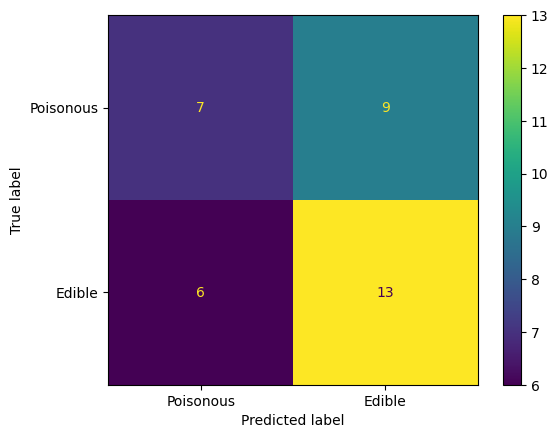

In [33]:
metrics.ConfusionMatrixDisplay.from_predictions(final_model.actual_class,final_model.pred_class, display_labels = ['Poisonous', 'Edible'])

In [35]:
TPR = 7/13
FPR = 9/22

print('The TPR is: ', TPR)
print('The FPR is: ', FPR)

The TPR is:  0.5384615384615384
The FPR is:  0.4090909090909091


In [38]:
def adjust_thres(x,y,z):
  #x=pred_probablities, y=threshold, z=test_outcome
  thres = (np.where(x > y, 1,0))
  #np.where is essentially a condensed if else statement. The first argument is the condition, then the true output, then the false output
  return metrics.ConfusionMatrixDisplay.from_predictions(z,thres, display_labels = [False, True])

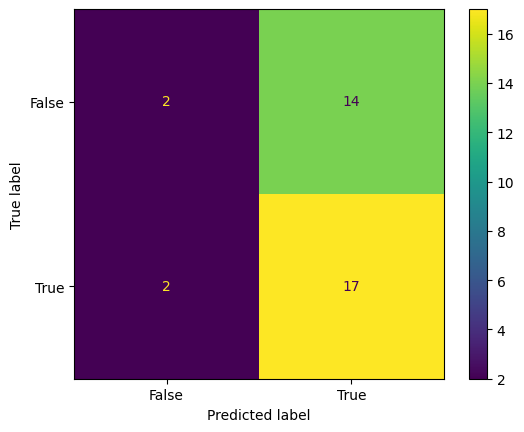

In [39]:
adjust_thres(final_model.pred_prob, 0.3, final_model.actual_class)

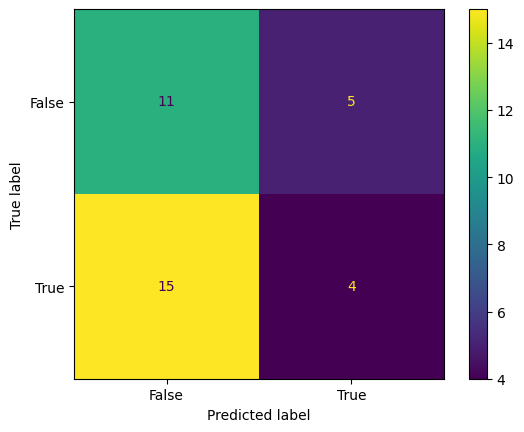

In [40]:
adjust_thres(final_model.pred_prob, 0.7, final_model.actual_class)

Text(0.5, 0, 'False Positive Rate')

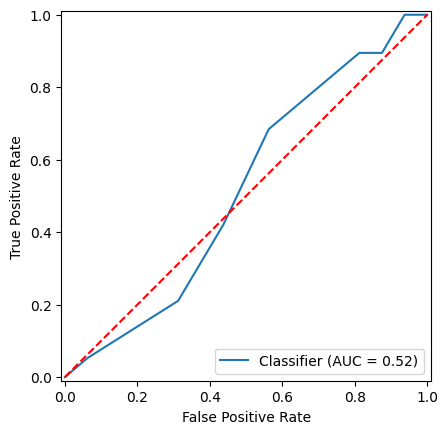

In [42]:
metrics.RocCurveDisplay.from_predictions(final_model.actual_class, final_model.pred_prob)
#Set labels and midline...
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')